# Projeto de análise sensorial do café. 

## 1. Apresentação da base de dados e contexto.

### Contexto do projeto

Este projeto utiliza a base de dados `df_arabica_clean.csv`, que contém informações detalhadas sobre a avaliação de qualidade de cafés arábica de diversas partes do mundo. Os dados incluem a origem do grão, método de processamento, e notas sensoriais dadas por especialistas (Armoma, sabor, acidez, corpo, etc).

### Objetivo

O objetivo deste projeto é explorar técnicas de Análise de Dados e Machine Learning aplicadas a uma base de dados sobre a qualidade de cafés. Inicialmente, é realizada uma análise exploratória para compreender as características da base, identificar padrões e visualizar as relações entre as variáveis.

Em seguida, são aplicadas diferentes abordagens de aprendizado de máquina. A Regressão Linear é utilizada para prever a pontuação total do café (Total Cup Points) a partir de suas características sensoriais. A Regressão Logística é empregada para classificar os cafés em categorias de qualidade (Premium e Padrão), enquanto o algoritmo K-Means é utilizado para identificar agrupamentos naturais entre cafés com características semelhantes.

Essas análises permitem compreender quais atributos exercem maior influência na qualidade do café, além de demonstrar diferentes aplicações de técnicas de Machine Learning em um mesmo conjunto de dados.

##### Import de bibliotecas necessárias. 

In [154]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

## 2. Análise exploratória de dados.

##### Carregamento da base de dados com tratamento de erro.

In [155]:
try:
    cafe = pd.read_csv('df_arabica_clean.csv')
    print("Arquivo carregado com sucesso!")
except FileNotFoundError:
    print("Erro: arquivo df_arabica_clean.csv não encontrado!")


Arquivo carregado com sucesso!


##### Exibindo as primeiras linhas para entendimento da estrutura.

In [156]:
display(cafe.head())

,Unnamed: 0,ID,Country of Origin,Farm Name,Lot Number,Mill,ICO Number,Company,Altitude,Region,...,Total Cup Points,Moisture Percentage,Category One Defects,Quakers,Color,Category Two Defects,Expiration,Certification Body,Certification Address,Certification Contact
0,0,0,Colombia,Finca El Paraiso,CQU2022015,Finca El Paraiso,NaN,Coffee Quality Union,1700-1930,"Piendamo,Cauca",...,89.33,11.8,0,0,green,3,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
1,1,1,Taiwan,Royal Bean Geisha Estate,"The 2022 Pacific Rim Coffee Summit,T037",Royal Bean Geisha Estate,NaN,Taiwan Coffee Laboratory,1200,Chiayi,...,87.58,10.5,0,0,blue-green,0,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
2,2,2,Laos,OKLAO coffee farms,"The 2022 Pacific Rim Coffee Summit,LA01",oklao coffee processing plant,NaN,Taiwan Coffee Laboratory,1300,Laos Borofen Plateau,...,87.42,10.4,0,0,yellowish,2,"November 15th, 2023",Taiwan Coffee Laboratory 台灣咖啡研究室,"QAHWAH CO., LTD 4F, No. 225, Sec. 3, Beixin Rd...","Lin, Jen-An Neil 林仁安 - 886-289116612"
3,3,3,Costa Rica,La Cumbre,CQU2022017,La Montana Tarrazu MIll,NaN,Coffee Quality Union,1900,"Los Santos,Tarrazu",...,87.17,11.8,0,0,green,0,"September 21st, 2023",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901
4,4,4,Colombia,Finca Santuario,CQU2023002,Finca Santuario,NaN,Coffee Quality Union,1850-2100,"Popayan,Cauca",...,87.08,11.6,0,2,yellow-green,2,"March 5th, 2024",Japan Coffee Exchange,"〒413-0002 静岡県熱海市伊豆山１１７３−５８ 1173-58 Izusan, Ata...",松澤 宏樹 Koju Matsuzawa - +81(0)9085642901


##### Selecionando as variáveis numéricas de interesse para a análise.

In [157]:
colunas_interesse = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total Cup Points']
cafe_analise = cafe[colunas_interesse].dropna().copy()
display(cafe_analise.describe())

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Total Cup Points
count,207.000000,207.000000,207.000000,207.00000,207.000000,207.000000,207.000000
mean,7.721063,7.744734,7.599758,7.69029,7.640918,7.644058,83.706570
std,0.287626,0.279613,0.275911,0.25951,0.233499,0.256299,1.730417
min,6.500000,6.750000,6.670000,6.83000,6.830000,6.670000,78.000000
25%,7.580000,7.580000,7.420000,7.50000,7.500000,7.500000,82.580000
50%,7.670000,7.750000,7.580000,7.67000,7.670000,7.670000,83.750000
75%,7.920000,7.920000,7.750000,7.87500,7.750000,7.790000,84.830000
max,8.580000,8.500000,8.420000,8.58000,8.250000,8.420000,89.330000


Através da função `describe()`, pode-se observar a mádia das notas sensoriais e da nota final (`Total Cup Pints`), bem como o desvio padrão, o que nos indica a dispersão da qualidade dos cafés avaliados. Nota-se que a maioria dos cafés possui notas sensoriais orbitando em torno de 7.5 a 8.5.  

##### Separando as variáveis independentes (X)

In [159]:
X = cafe_analise[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']]

print("Dados carregados com sucesso! Quantidade de registros:", len(cafe_analise))

Dados carregados com sucesso! Quantidade de registros: 207


## 3. Visualização gráfica e relações.

##### Gráfico 1: Histograma da variável alvo (Total Cup Points)

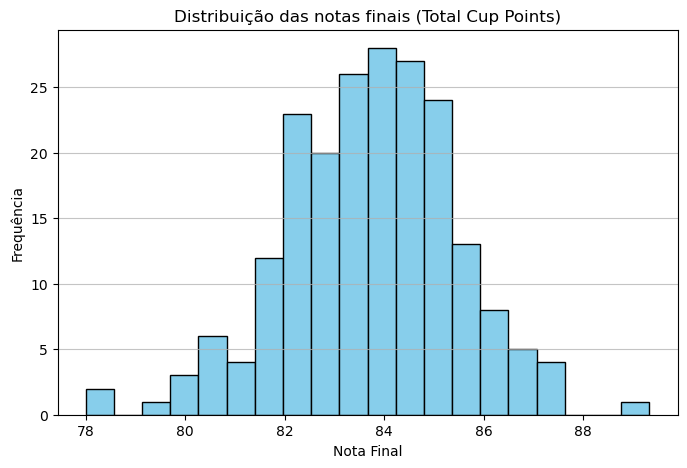

In [160]:
plt.figure(figsize=(8, 5))
plt.hist(cafe['Total Cup Points'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribuição das notas finais (Total Cup Points)')
plt.xlabel('Nota Final')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

##### Gráfico 2: Relação entre sabor (flavor) e nota final

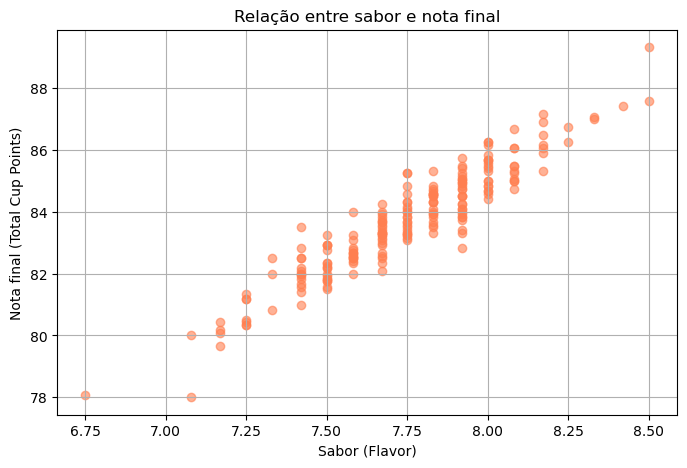

In [161]:
plt.figure(figsize=(8, 5))
plt.scatter(cafe['Flavor'], cafe['Total Cup Points'], color='coral', alpha=0.6)
plt.title('Relação entre sabor e nota final')
plt.xlabel('Sabor (Flavor)')
plt.ylabel('Nota final (Total Cup Points)')
plt.grid(True)
plt.show()

O histograma mostra como as notas finais estão distribuídas, com uma concentração evidente entre 82 e 86 pontos. O gráfico de dispersão (scatter plot) demonstra uma forte correlação linear positiva entre 'Flavor' (Sabor) e a nota final do café, idicando que o sabor é uma exelente preditor para o modelo.

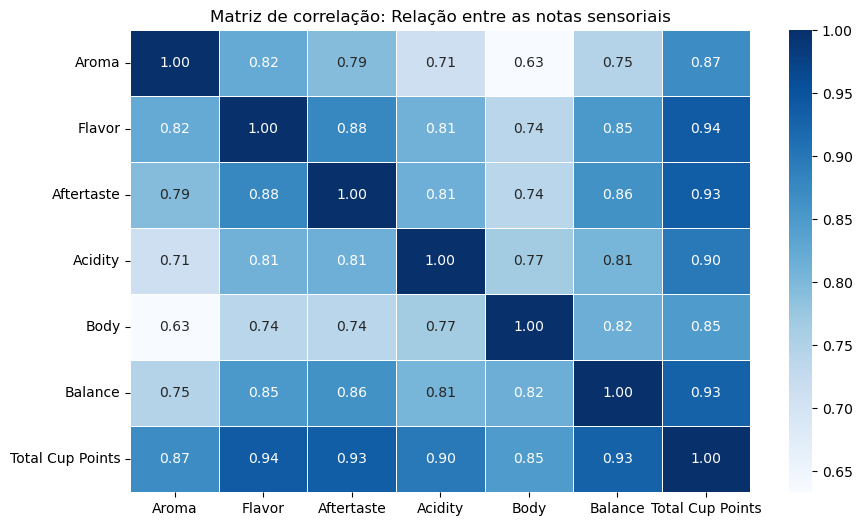

In [162]:
plt.figure(figsize=(10, 6))
matriz_correlacao = cafe_analise[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Total Cup Points']].corr()

sns.heatmap(matriz_correlacao, annot=True, cmap='Blues', fmt=".2f", linewidths=.5)
plt.title('Matriz de correlação: Relação entre as notas sensoriais')
plt.show()

A matriz de correlação permite identificar relações entre variáveis numéricas da base. Observa-se que atributos como Flavor, Aroma, Aftertaste e Overall possuem forte correlação positiva com a variável Total Cup Points, indicando que são importantes para prever a qualidade final do café.

## 4. Criação de modelos de machine learning.

Para demonstrar uma análise completa da base de dados, será aplicado três abordagens diferentes de machine learning: clustering (agrupamento), classificação e regressão.

<!-- **Justificativa do modelo:**

Optamos por um modelo de *Clustering* utilizando o algoritmo *K-Means*. O objetivo é decobrir se os dados se agrupam naturalmente em diferentes "perfis sensoriais" de café (por exemplo: cafés de qualidade excepcional, qualidade média e qualidade inferior) baseando-se apenas nas suas notas de sabor, aroma, acidez, etc., sem utilizar a nota final previamente.

**Sobre o método:**

Como o K-Means calcula distâncias matemáticas, é fundamental normalizar os dados antes. A divisão em treino e teste será feita para treinar os centróides no conjunto de treino e validar a consistência do agrupamento no conjunto de teste. A métrica de avaliação utilizada será o *Silhouette Score* (que mede o quão bem separados estão os clusters, substituindo as métricas de erro tradicionais de modelos supervisionados).

<!--
Como a variável alvo (`Total Cup Points`) é um valor numérico contínuo, então se tatra de um problema de *regressão*. Foi escolhido o modelo de *Regressão Linear Múltipla* (Utilizando a biblioteca `scikit-learn`) devido à forte relação linear observada na análise gráfica e pela facilidade de interpretação dos coeficientes.
-->

### 4.1 Modelo 1: Clustering (K-Means)

**Objetivo:** Descobrir perfis sensoriais de café agrupando-os por similaridade, sem olhar a nota final.

Como o K-Means calcula distância matemática, é fundamental normalizar os dados antes. A métrica de avaliação utiliza será o *Silhouette Score*.

##### Evitando avisos do KMeans

In [163]:
warnings.filterwarnings('ignore')

##### Separação da variáveis preditoras (X) e da variável alvo (Y).

In [164]:
x = cafe_analise[['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance']]
y = cafe_analise['Total Cup Points']

##### Padronização de dados (crucial para o K-Means).

In [165]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

##### Treinamento do modelo K-Means (buscando 3 perfis de café).

In [166]:
modelo_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cafe_analise['Cluster'] = modelo_kmeans.fit_predict(x_scaled)

##### Avaliação do agrupamento.

In [167]:
score_silhueta = silhouette_score(x_scaled, cafe_analise['Cluster'])
print(f"Silhouette Score (Qualidade da separação): {score_silhueta:.4f}")

Silhouette Score (Qualidade da separação): 0.3266


O modelo K-Means obteve um Silhouette Score de 0,3266. Essa métrica varia de -1 a 1, sendo que valores próximos de 1 indicam grupos bem definidos e separados, valores próximos de 0 indicam sobreposição entre os grupos e valores negativos sugerem agrupamentos inadequados.

O resultado obtido indica que os cafés foram agrupados com uma separação moderada, ou seja, existem diferenças entre os grupos identificados, embora ainda haja alguma semelhança entre eles. Esse comportamento é esperado em bases de dados com características sensoriais, nas quais diferentes perfis de cafés podem apresentar atributos próximos.

##### Exibindo a média das notas sensoriais para entender o perfil de cada Cluster.

In [168]:
display(cafe_analise.groupby('Cluster')[['Aroma', 'Flavor', 'Acidity']].mean().round(2))

,Aroma,Flavor,Acidity
Cluster,,,
0,7.38,7.37,7.35
1,7.99,8.01,7.92
2,7.66,7.70,7.66


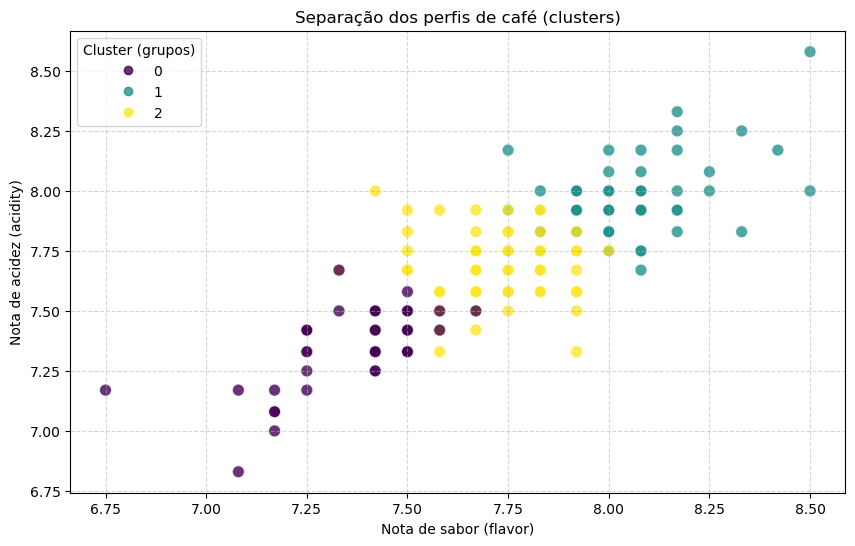

In [169]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(cafe_analise['Flavor'], cafe_analise['Acidity'],
                    c=cafe_analise['Cluster'], cmap='viridis',
                    alpha=0.8, edgecolors='w', s=80)

plt.title('Separação dos perfis de café (clusters)')
plt.xlabel('Nota de sabor (flavor)')
plt.ylabel('Nota de acidez (acidity)')
plt.legend(*scatter.legend_elements(), title="Cluster (grupos)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

A tabela apresenta a média das variáveis Aroma, Flavor e Acidity para cada um dos clusters identificados pelo algoritmo K-Means. Essas médias permitem caracterizar o perfil de cada grupo de cafés.

- Cluster 0: apresentou as menores médias entre os três grupos (Aroma = 7,38; Flavor = 7,37; Acidity = 7,35), indicando cafés com avaliações sensoriais mais baixas.

- Cluster 1: apresentou as maiores médias (Aroma = 7,99; Flavor = 8,01; Acidity = 7,92), representando cafés com melhor desempenho nas características avaliadas.

- Cluster 2: apresentou valores intermediários (Aroma = 7,66; Flavor = 7,70; Acidity = 7,66), indicando cafés com qualidade sensorial entre os clusters 0 e 1.

Esses resultados mostram que o algoritmo conseguiu separar os cafés em grupos com perfis sensoriais distintos, facilitando a identificação de padrões de qualidade dentro da base de dados.

Embora o Silhouette Score de 0,3266 indique uma separação moderada entre os grupos, a análise das médias demonstra que o algoritmo conseguiu distinguir três perfis de cafés: um grupo com notas mais elevadas, um intermediário e outro com notas mais baixas nas características sensoriais avaliadas.

### 4.2 Modelo 2: Classificação (Regressão logística)

**Objetivo:** Prever se o café é "Premium" (nota final >= 83 pontos) baseado apenas em suas caracteristicas sensoriais.

Transformamos a variável contínua da nota final em uma categoria (0 para padrão, 1 para premium) para treinar o classificador.

##### Criando a variável alvo categórica (1 = Premium, 0 = Padrão)

In [170]:
cafe_analise['Premium'] = (cafe_analise['Total Cup Points'] >= 83.0).astype(int)
y_class = cafe_analise['Premium']

##### Seperação em dados de treino e teste.

In [171]:
x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_scaled, y_class, test_size=0.2, random_state=42)

##### Instanciando e treinando o modelo.

In [172]:
modelo_classificacao = LogisticRegression()
modelo_classificacao.fit(x_train_c, y_train_c)

LogisticRegression()

##### Prediçoes e métricas.

In [173]:
y_pred_c = modelo_classificacao.predict(x_test_c)
print("Relatório de classificação (previsão de café premium):")
print(classification_report(y_test_c, y_pred_c))

Relatório de classificação (previsão de café premium):
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.96      1.00      0.98        26

    accuracy                           0.98        42
   macro avg       0.98      0.97      0.97        42
weighted avg       0.98      0.98      0.98        42



O relatório de classificação apresenta métricas que avaliam o desempenho do modelo de Regressão Logística na tarefa de classificar os cafés como Premium ou Padrão.

- Precisão (Precision): indica a proporção de classificações positivas que estavam corretas. O modelo obteve precisão de 1,00 para cafés da classe 0 e 0,96 para cafés da classe 1, demonstrando alta confiabilidade nas previsões realizadas.

- Revocação (Recall): representa a capacidade do modelo de identificar corretamente os cafés pertencentes a cada classe. Os resultados de 0,94 para a classe 0 e 1,00 para a classe 1 indicam que praticamente todos os cafés foram classificados corretamente.

- F1-score: corresponde à média harmônica entre precisão e revocação. Os valores de 0,97 e 0,98 mostram que o modelo apresenta um excelente equilíbrio entre essas duas métricas.

- Acurácia (Accuracy): o modelo alcançou 98% de acerto, classificando corretamente 41 dos 42 cafés presentes no conjunto de teste.

De modo geral, os resultados indicam que a Regressão Logística apresentou excelente desempenho na classificação dos cafés, demonstrando alta capacidade de distinguir cafés Premium dos cafés Padrão com baixo índice de erros.

### 4.3 Modelo 3: Regressão (regressão linear mútipla)

**Objetivo:** Prever o valor numérico exato da nota final (`Total Cup Points`) de um café.

Devido a forte relação linear observada na análise gráfica (Sabor vs Nota Final), a regressão linear múltipla é ideal para prever a pontuação exata baseada no conjunto de notas sensoriais.

##### Separação em dados de treino (80%) e teste (20%).

In [174]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##### Instanciando e treinando o modelo.

In [179]:
modelo_regressao = LinearRegression()
modelo_regressao.fit(x_train, y_train)

LinearRegression()

##### Descrições da métrica de erro.

In [176]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro quadrático médio (MSE): {mse:.4f}")
print(f"Erro absoluto médio (MAE): {mae:.4f}")
print(f"Coeficiente de determinação (R²): {r2:.4f}")

Erro quadrático médio (MSE): 0.0116
Erro absoluto médio (MAE): 0.0858
Coeficiente de determinação (R²): 0.9954


Para avaliar o desempenho da Regressão Linear, foram utilizadas as métricas Erro Quadrático Médio (MSE), Erro Absoluto Médio (MAE) e Coeficiente de Determinação (R²).

- Erro Quadrático Médio (MSE): o modelo apresentou um valor de 0,0116, indicando que a diferença média entre os valores previstos e os valores reais foi muito pequena. Quanto menor o MSE, melhor é o desempenho do modelo.

- Erro Absoluto Médio (MAE): o valor de 0,0858 significa que, em média, as previsões diferiram da pontuação real em aproximadamente 0,09 pontos, demonstrando alta precisão nas estimativas.

- Coeficiente de Determinação (R²): o modelo obteve um valor de 0,9954, indicando que aproximadamente 99,54% da variação da pontuação total dos cafés é explicada pelas variáveis utilizadas no modelo. Quanto mais próximo de 1, melhor o ajuste da regressão aos dados.

De modo geral, as métricas indicam que a Regressão Linear apresentou excelente desempenho, realizando previsões muito próximas dos valores reais e demonstrando alta capacidade de explicar a pontuação final dos cafés a partir de suas características sensoriais.

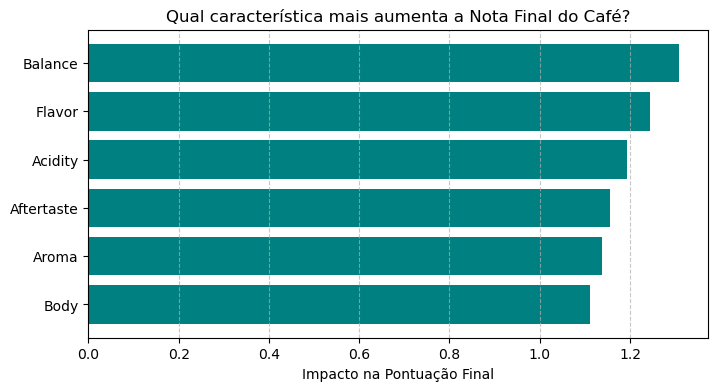

In [177]:
pesos = modelo_regressao.coef_

df_importancia = pd.DataFrame({
    'Caracteristicas': x.columns,
    'Peso no modelo': pesos
}).sort_values(by='Peso no modelo', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(df_importancia['Caracteristicas'], df_importancia['Peso no modelo'], color='teal')
plt.gca().invert_yaxis()
plt.title('Qual característica mais aumenta a Nota Final do Café?')
plt.xlabel('Impacto na Pontuação Final')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Os coeficientes mostram quais caracteristicas sensoriais possuem maior influência sobre a nota final do café. Valores positivos indicam aumento esperado da nota à medida que a variável cresce.

##### Exemplo de uso: Prevendo a nota de um café hipotético criado.

**Notas hipotéticas:**

- Aroma: 8.0;
- Flavor: 8.2;
- Aftertaste: 8.1;
- Acidity: 7.9;
- Body: 8.0;
- Balance: 8.0.

In [182]:
novo_cafe = pd.DataFrame({
    "Aroma":[8.5],
    "Flavor":[8.7],
    "Aftertaste":[8.4],
    "Acidity":[8.2],
    "Body":[7.4],
    "Balance":[7.9]
})

predicao = modelo_regressao.predict(novo_cafe)

print(f"A nota final prevista para o café hipotético é: {predicao[0]:.2f} pontos.")

A nota final prevista para o café hipotético é: 87.38 pontos.


## 5. Conclusão e Insights de Negócio

Os resultados obtidos demonstram que as técnicas de Machine Learning aplicadas foram eficazes para analisar a qualidade dos cafés da base de dados, permitindo identificar padrões, realizar previsões e segmentar os produtos de acordo com suas características sensoriais.

**Principais insights obtidos:**

1. **Fatores que influenciam a qualidade:** A análise de regressão mostrou que atributos sensoriais, especialmente Flavor, exercem forte influência sobre a pontuação final (Total Cup Points). Isso indica que investimentos na melhoria dessas características podem contribuir para a obtenção de cafés com maior qualidade.

2. **Classificação de cafés Premium:** O modelo de Regressão Logística apresentou 98% de acurácia, demonstrando elevada capacidade de classificar automaticamente cafés como Premium ou Padrão com base em suas avaliações sensoriais.

3. **Identificação de perfis de cafés:** O algoritmo K-Means identificou três grupos distintos de cafés, representando perfis sensoriais diferentes. Embora o Silhouette Score de 0,3266 indique uma separação moderada entre os grupos, foi possível distinguir cafés com avaliações sensoriais mais elevadas, intermediárias e mais baixas.

De forma geral, o projeto demonstrou como diferentes técnicas de aprendizado de máquina podem ser aplicadas sobre uma mesma base de dados para responder a diferentes problemas: prever pontuações, classificar cafés e identificar agrupamentos naturais. Esses resultados podem auxiliar produtores, avaliadores e empresas do setor cafeeiro na tomada de decisões relacionadas à qualidade dos produtos e ao direcionamento de estratégias de melhoria.